In [1]:
# =========================
# tests for models.py
# Put this cell in the same folder as models.py
# =========================

import numpy as np
import scipy.sparse as sp
import traceback

from models import (
    QWZModel,
    HaldaneModel,
    sample_impurity_sites,
    check_hermitian,
)

np.set_printoptions(precision=6, suppress=True)

def report(name, ok, detail=""):
    status = "PASS" if ok else "FAIL"
    print(f"[{status}] {name}")
    if detail:
        print(f"       {detail}")

def max_abs(A):
    if sp.issparse(A):
        if A.nnz == 0:
            return 0.0
        return np.max(np.abs(A.data))
    return np.max(np.abs(A))

def dense(A):
    return A.toarray() if sp.issparse(A) else np.asarray(A)

try:
    print("="*80)
    print("1. QWZModel basic construction")
    print("="*80)

    Lx, Ly = 6, 5
    t, u, A = 1.0, -2.05, 1.5
    q = QWZModel(Lx=Lx, Ly=Ly, t=t, u=u, A=A, pbc=True)

    report("QWZ dimension", q.dim == 2*Lx*Ly, f"dim={q.dim}, expected={2*Lx*Ly}")

    # idx uniqueness
    all_idx = [q.idx(x, y, orb) for y in range(Ly) for x in range(Lx) for orb in [0,1]]
    report(
        "QWZ idx uniqueness",
        len(set(all_idx)) == q.dim and min(all_idx) == 0 and max(all_idx) == q.dim-1,
        f"min={min(all_idx)}, max={max(all_idx)}, unique={len(set(all_idx))}",
    )

    # positions
    pos = q.positions()
    report("QWZ positions shape", pos.shape == (q.dim, 2), f"shape={pos.shape}")
    same_orb_pos = np.allclose(pos[q.idx(2,3,0)], pos[q.idx(2,3,1)])
    report("QWZ two orbitals share same position", same_orb_pos, f"pos={pos[q.idx(2,3,0)]}")

    print("\n" + "="*80)
    print("2. QWZ clean Hamiltonian: Hermiticity and sparse/dense consistency")
    print("="*80)

    H0_dense = q.clean_hamiltonian(sparse=False)
    H0_sparse = q.clean_hamiltonian(sparse=True)

    report("QWZ clean dense shape", H0_dense.shape == (q.dim, q.dim), f"shape={H0_dense.shape}")
    report("QWZ clean Hermitian dense", check_hermitian(H0_dense), f"max|H-H†|={max_abs(H0_dense-H0_dense.conj().T):.3e}")
    report("QWZ clean Hermitian sparse", check_hermitian(H0_sparse), f"nnz={H0_sparse.nnz}")

    diff_sparse_dense = dense(H0_sparse) - H0_dense
    report(
        "QWZ sparse/dense clean agree",
        np.allclose(diff_sparse_dense, 0, atol=1e-12),
        f"max diff={max_abs(diff_sparse_dense):.3e}",
    )

    print("\n" + "="*80)
    print("3. QWZ clean spectrum against Bloch spectrum")
    print("="*80)

    # For PBC clean QWZ, eigenvalues should be ±sqrt(A^2 sin^2 kx + A^2 sin^2 ky + mass^2)
    evals_real = np.linalg.eigvalsh(H0_dense)

    evals_k = []
    for nx in range(Lx):
        kx = 2*np.pi*nx/Lx
        for ny in range(Ly):
            ky = 2*np.pi*ny/Ly
            mass = u + t*np.cos(kx) + t*np.cos(ky)
            d = np.sqrt((A*np.sin(kx))**2 + (A*np.sin(ky))**2 + mass**2)
            evals_k.extend([-d, d])
    evals_k = np.array(sorted(evals_k))
    evals_real_sorted = np.array(sorted(evals_real))

    spec_diff = np.max(np.abs(evals_real_sorted - evals_k))
    report(
        "QWZ clean real-space spectrum matches Bloch spectrum",
        spec_diff < 1e-10,
        f"max spectrum diff={spec_diff:.3e}",
    )

    print("\n" + "="*80)
    print("4. Impurity sampling")
    print("="*80)

    density = 0.03
    imps1 = sample_impurity_sites(Lx, Ly, density=density, seed=123)
    imps2 = sample_impurity_sites(Lx, Ly, density=density, seed=123)
    imps3 = sample_impurity_sites(Lx, Ly, density=density, seed=124)

    n_expected = int(round(density * Lx * Ly))

    report("Fixed impurity number", len(imps1) == n_expected, f"n_imp={len(imps1)}, expected={n_expected}")
    report("Sampling reproducible with same seed", imps1 == imps2, f"imps1={imps1}")
    report("Different seed usually different", imps1 != imps3 or n_expected in [0, Lx*Ly], f"imps3={imps3}")

    imps_fixed = sample_impurity_sites(Lx, Ly, n_imp=4, seed=0)
    report("Sampling with explicit n_imp", len(imps_fixed) == 4, f"imps_fixed={imps_fixed}")
    report("No duplicate impurities", len(set(imps_fixed)) == len(imps_fixed), f"unique={len(set(imps_fixed))}")

    print("\n" + "="*80)
    print("5. QWZ impurity potential")
    print("="*80)

    h = -1.7
    single_imp = [(1, 2)]
    V = q.impurity_potential(single_imp, h=h, sparse=False)

    # V_R = -h sigma_z = diag(-h, +h) on impurity site
    expected_block = np.array([[-h, 0], [0, h]], dtype=complex)
    actual_block = V[np.ix_([q.idx(1,2,0), q.idx(1,2,1)], [q.idx(1,2,0), q.idx(1,2,1)])]

    report(
        "QWZ impurity onsite block correct",
        np.allclose(actual_block, expected_block, atol=1e-12),
        f"actual block=\n{actual_block}\nexpected block=\n{expected_block}",
    )

    V_nonzero = np.count_nonzero(np.abs(V) > 1e-12)
    report("QWZ single impurity has only two nonzero diagonal entries", V_nonzero == 2, f"nonzero entries={V_nonzero}")

    H_full = q.hamiltonian(impurities=single_imp, h=h, sparse=False)
    report(
        "QWZ full H = H0 + V",
        np.allclose(H_full, H0_dense + V, atol=1e-12),
        f"max diff={max_abs(H_full - (H0_dense + V)):.3e}",
    )
    report("QWZ full Hamiltonian Hermitian", check_hermitian(H_full), f"max|H-H†|={max_abs(H_full-H_full.conj().T):.3e}")

    print("\n" + "="*80)
    print("6. QWZ open boundary smoke test")
    print("="*80)

    q_open = QWZModel(Lx=4, Ly=3, t=1.0, u=-2.05, A=1.5, pbc=False)
    H_open = q_open.clean_hamiltonian(sparse=False)
    report("QWZ OBC shape", H_open.shape == (q_open.dim, q_open.dim), f"shape={H_open.shape}")
    report("QWZ OBC Hermitian", check_hermitian(H_open), f"max|H-H†|={max_abs(H_open-H_open.conj().T):.3e}")

    print("\n" + "="*80)
    print("7. HaldaneModel clean Hamiltonian smoke tests")
    print("="*80)

    hm = HaldaneModel(Lx=5, Ly=4, t1=1.0, t2=0.1, m=0.2, pbc=True)
    HH_dense = hm.clean_hamiltonian(sparse=False)
    HH_sparse = hm.clean_hamiltonian(sparse=True)

    report("Haldane dimension", hm.dim == 2*5*4, f"dim={hm.dim}")
    report("Haldane positions shape", hm.positions().shape == (hm.dim, 2), f"shape={hm.positions().shape}")
    report("Haldane clean dense shape", HH_dense.shape == (hm.dim, hm.dim), f"shape={HH_dense.shape}")
    report("Haldane clean Hermitian dense", check_hermitian(HH_dense), f"max|H-H†|={max_abs(HH_dense-HH_dense.conj().T):.3e}")
    report("Haldane clean Hermitian sparse", check_hermitian(HH_sparse), f"nnz={HH_sparse.nnz}")

    hd_diff = dense(HH_sparse) - HH_dense
    report(
        "Haldane sparse/dense clean agree",
        np.allclose(hd_diff, 0, atol=1e-12),
        f"max diff={max_abs(hd_diff):.3e}",
    )

    print("\n" + "="*80)
    print("8. Haldane impurity intentionally not implemented")
    print("="*80)

    try:
        _ = hm.hamiltonian(impurities=[(0,0)], h=0.5, sparse=False)
        report("Haldane impurity raises NotImplementedError", False, "No error was raised.")
    except NotImplementedError as e:
        report("Haldane impurity raises NotImplementedError", True, str(e))

    print("\n" + "="*80)
    print("SUMMARY")
    print("="*80)
    print("If all lines above are PASS, models.py is ready for the next step:")
    print("observables.py: diagonalization, Bott index, spectral gap, IPR, impurity weight.")

except Exception as e:
    print("\n" + "="*80)
    print("UNEXPECTED ERROR")
    print("="*80)
    print(type(e).__name__, str(e))
    traceback.print_exc()

1. QWZModel basic construction
[PASS] QWZ dimension
       dim=60, expected=60
[PASS] QWZ idx uniqueness
       min=0, max=59, unique=60
[PASS] QWZ positions shape
       shape=(60, 2)
[PASS] QWZ two orbitals share same position
       pos=[2. 3.]

2. QWZ clean Hamiltonian: Hermiticity and sparse/dense consistency
[PASS] QWZ clean dense shape
       shape=(60, 60)
[PASS] QWZ clean Hermitian dense
       max|H-H†|=0.000e+00
[PASS] QWZ clean Hermitian sparse
       nnz=540
[PASS] QWZ sparse/dense clean agree
       max diff=0.000e+00

3. QWZ clean spectrum against Bloch spectrum
[PASS] QWZ clean real-space spectrum matches Bloch spectrum
       max spectrum diff=5.773e-15

4. Impurity sampling
[PASS] Fixed impurity number
       n_imp=1, expected=1
[PASS] Sampling reproducible with same seed
       imps1=[(0, 0)]
[PASS] Different seed usually different
       imps3=[(2, 4)]
[PASS] Sampling with explicit n_imp
       imps_fixed=[(2, 1), (2, 2), (4, 3), (5, 2)]
[PASS] No duplicate impuriti


1. Clean QWZ Bott index sanity check


,u,Bott,round(B),|round(B)|,gap,n_occ,W_eig_abs_min,W_eig_abs_max
0,-3.0,-9.784623e-16,0,0,2.0,256,1.0,1.0
1,-1.0,1.000000e+00,1,1,2.0,256,1.0,1.0
2,1.0,-1.000000e+00,-1,1,2.0,256,1.0,1.0
3,3.0,-3.087789e-15,0,0,2.0,256,1.0,1.0



Expected sanity check:
  u=-3, +3 should be trivial: round(B) ~ 0
  u=-1, +1 should be topological: |round(B)| ~ 1
  The sign of Bott may differ from the draft convention; that is okay for now.

2. Single disordered QWZ sample diagnostics
L                                            : 16
dim                                          : 512
density                                      : 0.03
n_imp                                        : 8
first few impurities                         : [(13, 0), (3, 0), (7, 3), (1, 4), (5, 14), (15, 2), (10, 10), (4, 9)]
Hermitian                                    : True
Bott                                         : 1.0000000000000013
round(Bott)                                  : 1
spectral gap                                 : 0.09636612299835778
HOMO                                         : -0.04818306149917853
LUMO                                         : 0.04818306149917925
closest-to-EF energy                         : -0.04818306149917853
IPR 

,h,L,n_samples,mean_B,std_B,mean_round_B,P_|B|=1,P_B=0,P_B=+1,P_B=-1,mean_gap,mean_|E0|,mean_IPR0,mean_PR0,mean_Wimp0
0,0.0,16,8,4.947530e-16,0.000000e+00,0.0,0.0,1.0,0.0,0.0,0.100000,0.050000,0.003906,256.000000,0.245605
1,-1.0,16,8,3.489775e-16,2.787359e-15,0.0,0.0,1.0,0.0,0.0,0.013686,0.006843,0.003933,254.264453,0.270392
2,-1.4,16,8,1.000000e+00,2.229547e-15,1.0,1.0,0.0,1.0,0.0,0.040285,0.020143,0.004042,247.419887,0.290670
3,-1.7,16,8,1.000000e+00,3.889630e-15,1.0,1.0,0.0,1.0,0.0,0.090172,0.045086,0.004169,239.973209,0.306572
4,-2.0,16,8,1.000000e+00,2.310224e-15,1.0,1.0,0.0,1.0,0.0,0.150496,0.075248,0.004495,222.764608,0.331418
5,-2.4,16,8,1.000000e+00,1.840618e-15,1.0,1.0,0.0,1.0,0.0,0.231435,0.115717,0.005061,198.317458,0.355908
6,-2.8,16,8,1.000000e+00,2.656925e-15,1.0,1.0,0.0,1.0,0.0,0.309941,0.154971,0.006923,145.815801,0.443198
7,-3.2,16,8,1.000000e+00,2.882307e-15,1.0,1.0,0.0,1.0,0.0,0.154069,0.077035,0.034608,33.205176,0.707136
8,-3.6,16,8,-1.998407e-15,2.067401e-15,0.0,0.0,1.0,0.0,0.0,0.104477,0.052238,0.033602,31.088372,0.766010
9,-4.0,16,8,-9.563751e-16,1.684727e-15,0.0,0.0,1.0,0.0,0.0,0.319275,0.159638,0.022069,47.114580,0.655321



Interpretation guide:
  - Near h=0, since u=-2.05 is clean trivial, expect Bott around 0.
  - Around h_TAI ≈ -1.67, average-mass estimate suggests entering topological region.
  - At more negative h, RNAB Fig. 2-like behavior may eventually leave that region again.
  - With L=16 and only 8 samples, do NOT expect a clean phase boundary.
  - A meaningful result here is just a visible trend in P_|B|=1 or mean_B.

4. Quick plots


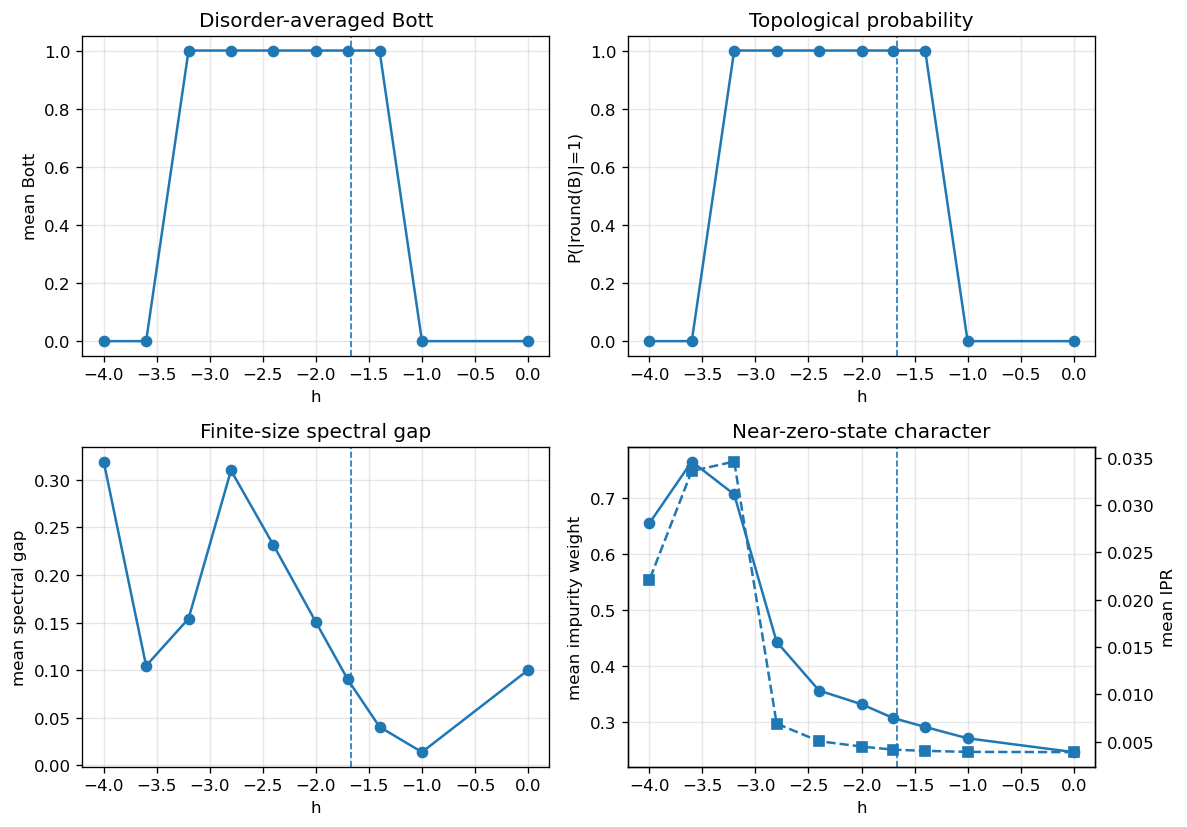


5. Timing
Total elapsed time: 42.72 seconds
If this is much less than 10 minutes, next step can use L=20/24 or n_samples=20.
If this is already slow, keep L=16 and reduce h points before moving to PACE.


In [3]:
# ============================================================
# One-cell test for models.py + observables.py
# Put this notebook in the same folder as models.py / observables.py
# ============================================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from models import QWZModel, HaldaneModel, sample_impurity_sites, check_hermitian
from observables import (
    diagonalize,
    spectral_gap,
    bott_index,
    near_fermi_indices,
    ipr,
    participation_ratio,
    impurity_weight,
    summarize_near_fermi_state,
)

np.set_printoptions(precision=6, suppress=True)

t0 = time.time()

def banner(s):
    print("\n" + "="*90)
    print(s)
    print("="*90)

def short_report(name, value):
    print(f"{name:45s}: {value}")

# ------------------------------------------------------------
# 1. Clean QWZ Bott index sanity check
# ------------------------------------------------------------
banner("1. Clean QWZ Bott index sanity check")

# Use modest size. Increase to L_clean=20/24 later if this is fast.
L_clean = 16
A_clean = 1.5
t_clean = 1.0

# QWZ expected phases for t>0:
# |u|>2 -> trivial
# -2<u<0 -> Chern +/-1
# 0<u<2 -> Chern opposite sign
# sign may be flipped by our real-space convention, so only |B| matters initially.
u_list = [-3.0, -1.0, 1.0, 3.0]

clean_rows = []
for u in u_list:
    model = QWZModel(Lx=L_clean, Ly=L_clean, t=t_clean, u=u, A=A_clean, pbc=True)
    H = model.clean_hamiltonian(sparse=False)
    evals, evecs = diagonalize(H)
    gap = spectral_gap(evals)
    Bdet = bott_index(
        evals, evecs, model.positions(), model.Lx, model.Ly,
        fermi_energy=0.0, return_details=True
    )
    clean_rows.append({
        "u": u,
        "Bott": Bdet["bott"],
        "round(B)": Bdet["bott_round"],
        "|round(B)|": abs(Bdet["bott_round"]),
        "gap": gap["gap"],
        "n_occ": Bdet["n_occ"],
        "W_eig_abs_min": Bdet["eig_min_abs_W"],
        "W_eig_abs_max": Bdet["eig_max_abs_W"],
    })

clean_df = pd.DataFrame(clean_rows)
display(clean_df)

print("\nExpected sanity check:")
print("  u=-3, +3 should be trivial: round(B) ~ 0")
print("  u=-1, +1 should be topological: |round(B)| ~ 1")
print("  The sign of Bott may differ from the draft convention; that is okay for now.")

# ------------------------------------------------------------
# 2. One impurity sample: Hamiltonian + diagnostics
# ------------------------------------------------------------
banner("2. Single disordered QWZ sample diagnostics")

L0 = 16
params = dict(t=1.0, u=-2.05, A=1.5, pbc=True)
density = 0.03
h_test = -1.7
seed = 123

model = QWZModel(Lx=L0, Ly=L0, **params)
impurities = sample_impurity_sites(L0, L0, density=density, seed=seed)
H = model.hamiltonian(impurities=impurities, h=h_test, sparse=False)

short_report("L", L0)
short_report("dim", model.dim)
short_report("density", density)
short_report("n_imp", len(impurities))
short_report("first few impurities", impurities[:10])
short_report("Hermitian", check_hermitian(H))

evals, evecs = diagonalize(H)
gap = spectral_gap(evals)
Bdet = bott_index(
    evals, evecs, model.positions(), model.Lx, model.Ly,
    fermi_energy=0.0, return_details=True
)
near_diag = summarize_near_fermi_state(
    evals, evecs, model, impurities=impurities,
    fermi_energy=0.0, radius=1.5
)

short_report("Bott", Bdet["bott"])
short_report("round(Bott)", Bdet["bott_round"])
short_report("spectral gap", gap["gap"])
short_report("HOMO", gap["homo"])
short_report("LUMO", gap["lumo"])
short_report("closest-to-EF energy", near_diag["E0"])
short_report("IPR closest state", near_diag["ipr0"])
short_report("PR closest state", near_diag["pr0"])
short_report("impurity weight closest state", near_diag["wimp0"])

# ------------------------------------------------------------
# 3. Tiny RNAB-like scan: QWZ, u=-2.05, density=0.03, fixed A=1.5
# ------------------------------------------------------------
banner("3. Tiny RNAB-like QWZ scan along h")

print("This is intentionally small. It is NOT final finite-size scaling.")
print("Goal: see whether a small system already shows rough Bott changes.")
print("RNAB-like setting: u=-2.05, density=0.03, scan h at fixed A.")

# Keep this modest. If too slow, reduce L_scan or n_samples.
L_scan = 16
n_samples = 8

# Include points around average-mass estimate h_TAI ≈ -1.67
# and deeper negative h where impurity-band transition may occur.
h_list = np.array([
    0.0,
    -1.0,
    -1.4,
    -1.7,
    -2.0,
    -2.4,
    -2.8,
    -3.2,
    -3.6,
    -4.0,
])

scan_rows = []
model_scan = QWZModel(Lx=L_scan, Ly=L_scan, **params)

for h in h_list:
    Bs = []
    Brs = []
    gaps = []
    iprs = []
    prs = []
    wimps = []
    e0s = []

    for s in range(n_samples):
        # deterministic seed depending on h index and sample
        seed_s = 10000 + 1000*int(round(abs(h)*10)) + s

        impurities_s = sample_impurity_sites(
            L_scan, L_scan, density=density, seed=seed_s
        )
        Hs = model_scan.hamiltonian(
            impurities=impurities_s, h=float(h), sparse=False
        )
        evals_s, evecs_s = diagonalize(Hs)

        Bd = bott_index(
            evals_s, evecs_s, model_scan.positions(),
            model_scan.Lx, model_scan.Ly,
            fermi_energy=0.0, return_details=True
        )
        gd = spectral_gap(evals_s)
        nd = summarize_near_fermi_state(
            evals_s, evecs_s, model_scan,
            impurities=impurities_s,
            fermi_energy=0.0,
            radius=1.5,
        )

        Bs.append(Bd["bott"])
        Brs.append(Bd["bott_round"])
        gaps.append(gd["gap"])
        iprs.append(nd["ipr0"])
        prs.append(nd["pr0"])
        wimps.append(nd["wimp0"])
        e0s.append(nd["E0"])

    Brs = np.array(Brs)
    Bs = np.array(Bs)

    scan_rows.append({
        "h": h,
        "L": L_scan,
        "n_samples": n_samples,
        "mean_B": np.mean(Bs),
        "std_B": np.std(Bs, ddof=1) if n_samples > 1 else 0.0,
        "mean_round_B": np.mean(Brs),
        "P_|B|=1": np.mean(np.abs(Brs) == 1),
        "P_B=0": np.mean(Brs == 0),
        "P_B=+1": np.mean(Brs == 1),
        "P_B=-1": np.mean(Brs == -1),
        "mean_gap": np.mean(gaps),
        "mean_|E0|": np.mean(np.abs(e0s)),
        "mean_IPR0": np.mean(iprs),
        "mean_PR0": np.mean(prs),
        "mean_Wimp0": np.mean(wimps),
    })

scan_df = pd.DataFrame(scan_rows)
display(scan_df)

print("\nInterpretation guide:")
print("  - Near h=0, since u=-2.05 is clean trivial, expect Bott around 0.")
print("  - Around h_TAI ≈ -1.67, average-mass estimate suggests entering topological region.")
print("  - At more negative h, RNAB Fig. 2-like behavior may eventually leave that region again.")
print("  - With L=16 and only 8 samples, do NOT expect a clean phase boundary.")
print("  - A meaningful result here is just a visible trend in P_|B|=1 or mean_B.")

# ------------------------------------------------------------
# 4. Quick plots
# ------------------------------------------------------------
banner("4. Quick plots")

fig, axes = plt.subplots(2, 2, figsize=(10, 7), dpi=120)

ax = axes[0, 0]
ax.errorbar(scan_df["h"], scan_df["mean_B"], yerr=scan_df["std_B"], marker="o", capsize=3)
ax.axvline(-1.67, linestyle="--", linewidth=1)
ax.set_xlabel("h")
ax.set_ylabel("mean Bott")
ax.set_title("Disorder-averaged Bott")
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(scan_df["h"], scan_df["P_|B|=1"], marker="o")
ax.axvline(-1.67, linestyle="--", linewidth=1)
ax.set_xlabel("h")
ax.set_ylabel("P(|round(B)|=1)")
ax.set_ylim(-0.05, 1.05)
ax.set_title("Topological probability")
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.plot(scan_df["h"], scan_df["mean_gap"], marker="o")
ax.axvline(-1.67, linestyle="--", linewidth=1)
ax.set_xlabel("h")
ax.set_ylabel("mean spectral gap")
ax.set_title("Finite-size spectral gap")
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(scan_df["h"], scan_df["mean_Wimp0"], marker="o", label="impurity weight")
ax2 = ax.twinx()
ax2.plot(scan_df["h"], scan_df["mean_IPR0"], marker="s", linestyle="--", label="IPR")
ax.axvline(-1.67, linestyle="--", linewidth=1)
ax.set_xlabel("h")
ax.set_ylabel("mean impurity weight")
ax2.set_ylabel("mean IPR")
ax.set_title("Near-zero-state character")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. Timing summary
# ------------------------------------------------------------
banner("5. Timing")
elapsed = time.time() - t0
print(f"Total elapsed time: {elapsed:.2f} seconds")
print("If this is much less than 10 minutes, next step can use L=20/24 or n_samples=20.")
print("If this is already slow, keep L=16 and reduce h points before moving to PACE.")

In [5]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from models import QWZModel, sample_impurity_sites, check_hermitian
from observables import (
    diagonalize,
    bott_index,
    spectral_gap,
    summarize_near_fermi_state,
    impurity_mask,
)

# ============================================================
# Laptop pilot scan: QWZ, fixed A cut
# ============================================================

t = 1.0
u = -2.05
A = 1.5
density = 0.03
radius = 1.5
base_seed = 20260708

# Start with [16, 20]. Add 24 only if runtime is acceptable.
L_list = [16, 20]
# L_list = [16, 20, 24]

h_values = np.array([
    0.0,
    -0.8, -1.0, -1.2, -1.4, -1.6, -1.8, -2.0,
    -2.4, -2.8, -3.0, -3.2, -3.4, -3.6, -3.8, -4.0
])

n_samples = 20

rows = []
t_start = time.time()

for L in L_list:
    print(f"\n===== L={L} =====")
    model = QWZModel(Lx=L, Ly=L, t=t, u=u, A=A, pbc=True)

    # Use the same disorder samples for all h at fixed L.
    # This reduces artificial h-to-h noise.
    impurity_list = []
    for s in range(n_samples):
        seed = base_seed + 10000 * L + s
        imps = sample_impurity_sites(L, L, density=density, seed=seed)
        impurity_list.append(imps)

    for ih, h in enumerate(h_values):
        print(f"  h={h: .2f}", end="", flush=True)
        t_h = time.time()

        for s, impurities in enumerate(impurity_list):
            H = model.hamiltonian(impurities=impurities, h=h, sparse=False)

            if s == 0 and ih == 0:
                assert check_hermitian(H)

            evals, evecs = diagonalize(H)

            bd = bott_index(
                evals,
                evecs,
                model.positions(),
                model.Lx,
                model.Ly,
                fermi_energy=0.0,
                return_details=True,
            )

            gap = spectral_gap(evals, fermi_energy=0.0)
            near = summarize_near_fermi_state(
                evals,
                evecs,
                model,
                impurities=impurities,
                fermi_energy=0.0,
                radius=radius,
            )

            mask = impurity_mask(model, impurities, radius=radius)
            f_mask = float(np.mean(mask))

            wimp = near["wimp0"]
            wimp_ratio = wimp / f_mask if f_mask > 0 else np.nan
            wimp_excess = wimp - f_mask

            rows.append({
                "L": L,
                "h": h,
                "sample": s,
                "n_imp": len(impurities),
                "B": bd["bott"],
                "B_round": bd["bott_round"],
                "gap": gap["gap"],
                "homo": gap["homo"],
                "lumo": gap["lumo"],
                "E0": near["E0"],
                "abs_E0": near["abs_E0_minus_EF"],
                "IPR0": near["ipr0"],
                "PR0": near["pr0"],
                "IPR0_scaled_L2": near["ipr0"] * L * L,
                "Wimp0": wimp,
                "f_mask": f_mask,
                "Wimp_ratio": wimp_ratio,
                "Wimp_excess": wimp_excess,
            })

        print(f"  done in {time.time() - t_h:.1f} s")

raw_df = pd.DataFrame(rows)
raw_df.to_csv("q wz_laptop_pilot_raw.csv".replace(" ", ""), index=False)

def prob_eq(x, val):
    x = np.asarray(x)
    return np.mean(x == val)

def prob_abs_eq(x, val):
    x = np.asarray(x)
    return np.mean(np.abs(x) == val)

summary = (
    raw_df
    .groupby(["L", "h"])
    .agg(
        n_samples=("sample", "count"),
        mean_B=("B", "mean"),
        std_B=("B", "std"),
        P_top_abs=("B_round", lambda x: prob_abs_eq(x, 1)),
        P_B0=("B_round", lambda x: prob_eq(x, 0)),
        P_Bp1=("B_round", lambda x: prob_eq(x, 1)),
        P_Bm1=("B_round", lambda x: prob_eq(x, -1)),
        mean_gap=("gap", "mean"),
        std_gap=("gap", "std"),
        mean_abs_E0=("abs_E0", "mean"),
        mean_IPR0_scaled_L2=("IPR0_scaled_L2", "mean"),
        mean_PR0=("PR0", "mean"),
        mean_Wimp0=("Wimp0", "mean"),
        mean_f_mask=("f_mask", "mean"),
        mean_Wimp_ratio=("Wimp_ratio", "mean"),
        mean_Wimp_excess=("Wimp_excess", "mean"),
    )
    .reset_index()
)

summary.to_csv("q wz_laptop_pilot_summary.csv".replace(" ", ""), index=False)
display(summary)

print(f"\nTotal elapsed: {(time.time() - t_start)/60:.2f} minutes")


===== L=16 =====
  done in 11.9 s
  done in 13.0 s
  done in 12.6 s
  done in 12.2 s
  done in 12.5 s
  done in 13.5 s
  done in 13.0 s
  done in 12.9 s
  done in 12.8 s
  done in 13.3 s
  done in 13.1 s
  done in 12.9 s
  done in 12.6 s
  done in 13.3 s
  done in 13.4 s
  done in 11.5 s

===== L=20 =====
  done in 25.6 s
  done in 24.8 s
  done in 25.4 s
  done in 25.1 s
  done in 24.6 s
  done in 25.9 s
  done in 24.9 s
  done in 25.7 s
  done in 23.1 s
  done in 25.6 s
  done in 25.6 s
  done in 25.0 s
  done in 24.5 s
  done in 24.6 s
  done in 25.1 s
  done in 27.6 s


,L,h,n_samples,mean_B,std_B,P_top_abs,P_B0,P_Bp1,P_Bm1,mean_gap,std_gap,mean_abs_E0,mean_IPR0_scaled_L2,mean_PR0,mean_Wimp0,mean_f_mask,mean_Wimp_ratio,mean_Wimp_excess
0,16,-4.0,20,-3.885550e-16,2.547492e-15,0.0,1.0,0.0,0.0,0.320444,0.019901,0.160222,5.843076,46.485227,0.658825,0.253906,2.600916,4.049185e-01
1,16,-3.8,20,1.166259e-15,2.962402e-15,0.0,1.0,0.0,0.0,0.217668,0.022228,0.108834,7.432442,35.483083,0.743920,0.253906,2.940854,4.900133e-01
2,16,-3.6,20,-2.125892e-18,2.553907e-15,0.0,1.0,0.0,0.0,0.094877,0.018820,0.047439,8.066973,33.322907,0.784436,0.253906,3.100161,5.305293e-01
3,16,-3.4,20,1.000000e+00,3.126313e-15,1.0,0.0,1.0,0.0,0.037399,0.013372,0.018699,9.313376,28.560126,0.780283,0.253906,3.082183,5.263771e-01
4,16,-3.2,20,1.000000e+00,3.288427e-15,1.0,0.0,1.0,0.0,0.170990,0.013851,0.085495,9.310086,28.793468,0.726603,0.253906,2.868474,4.726967e-01
5,16,-3.0,20,1.000000e+00,2.793845e-15,1.0,0.0,1.0,0.0,0.272066,0.026616,0.136033,4.015645,68.534103,0.581232,0.253906,2.290236,3.273253e-01
6,16,-2.8,20,1.000000e+00,2.806009e-15,1.0,0.0,1.0,0.0,0.300376,0.041978,0.150188,1.788504,144.399695,0.438280,0.253906,1.727993,1.843738e-01
7,16,-2.4,20,1.000000e+00,2.963101e-15,1.0,0.0,1.0,0.0,0.234570,0.026434,0.117285,1.300599,197.376871,0.357206,0.253906,1.408444,1.033000e-01
8,16,-2.0,20,1.000000e+00,2.189406e-15,1.0,0.0,1.0,0.0,0.147896,0.011543,0.073948,1.135145,225.886473,0.323859,0.253906,1.276623,6.995274e-02
9,16,-1.8,20,1.000000e+00,3.388215e-15,1.0,0.0,1.0,0.0,0.108231,0.006987,0.054116,1.085197,236.107569,0.310871,0.253906,1.225438,5.696462e-02



Total elapsed: 10.13 minutes


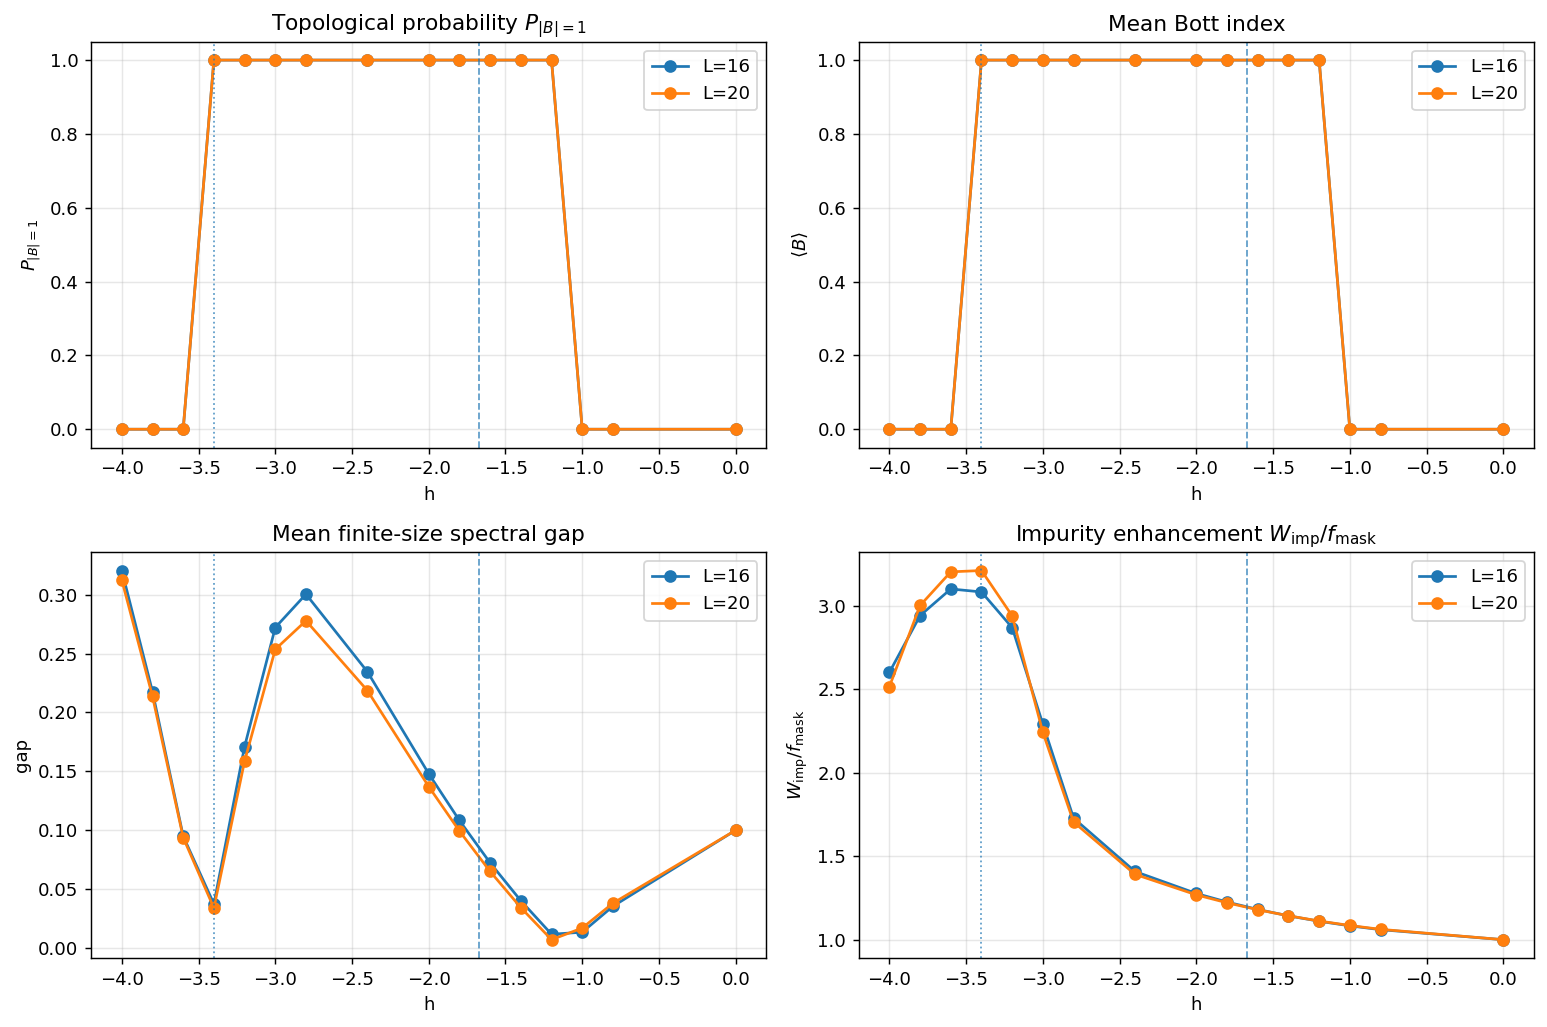

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=130)

for L in L_list:
    d = summary[summary["L"] == L].sort_values("h")

    axes[0, 0].plot(d["h"], d["P_top_abs"], marker="o", label=f"L={L}")
    axes[0, 1].plot(d["h"], d["mean_B"], marker="o", label=f"L={L}")
    axes[1, 0].plot(d["h"], d["mean_gap"], marker="o", label=f"L={L}")
    axes[1, 1].plot(d["h"], d["mean_Wimp_ratio"], marker="o", label=f"L={L}")

for ax in axes.flat:
    ax.axvline(-1.67, linestyle="--", linewidth=1, alpha=0.7)
    ax.axvline(-3.4, linestyle=":", linewidth=1, alpha=0.7)
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[0, 0].set_title(r"Topological probability $P_{|B|=1}$")
axes[0, 0].set_xlabel("h")
axes[0, 0].set_ylabel(r"$P_{|B|=1}$")

axes[0, 1].set_title(r"Mean Bott index")
axes[0, 1].set_xlabel("h")
axes[0, 1].set_ylabel(r"$\langle B\rangle$")

axes[1, 0].set_title("Mean finite-size spectral gap")
axes[1, 0].set_xlabel("h")
axes[1, 0].set_ylabel("gap")

axes[1, 1].set_title(r"Impurity enhancement $W_{\rm imp}/f_{\rm mask}$")
axes[1, 1].set_xlabel("h")
axes[1, 1].set_ylabel(r"$W_{\rm imp}/f_{\rm mask}$")

plt.tight_layout()
plt.show()

In [7]:
def estimate_crossing(summary, L, h_min, h_max, prob_col="P_top_abs", target=0.5):
    d = summary[
        (summary["L"] == L)
        & (summary["h"] >= h_min)
        & (summary["h"] <= h_max)
    ].sort_values("h")

    hs = d["h"].to_numpy()
    ps = d[prob_col].to_numpy()

    for i in range(len(hs) - 1):
        y1 = ps[i] - target
        y2 = ps[i + 1] - target

        if y1 == 0:
            return hs[i]

        if y1 * y2 < 0:
            # linear interpolation
            return hs[i] + (target - ps[i]) * (hs[i + 1] - hs[i]) / (ps[i + 1] - ps[i])

    return np.nan


for L in sorted(summary["L"].unique()):
    hc_left = estimate_crossing(summary, L, -3.70, -3.30)
    hc_right = estimate_crossing(summary, L, -1.28, -0.96)
    print(f"L={L}: hc_left={hc_left}, hc_right={hc_right}")

L=16: hc_left=-3.5, hc_right=-1.1
L=20: hc_left=-3.5, hc_right=-1.1
